In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Função para calcular o Nash-Sutcliffe Efficiency (NSE)
# Métrica fundamental em hidrologia e usada no paper ML4FF
def calculate_nse(targets, predictions):
    return 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [18]:
def read_csv(path: str) -> pd.DataFrame:
    """Reads a CSV file into a Pandas DataFrame.

    Args:
        path (str): The path to the CSV file.

    Returns:
        pd.DataFrame: A DataFrame containing the data from the CSV file.
    """

    return pd.read_csv(path)


def into_txt(data: pd.DataFrame, file_name: str) -> None:
    """Writes a Pandas DataFrame to a text file.

    Args:
        data (pd.DataFrame): The DataFrame to be written to the text file.
        file_name (str): The name of the text file to be created.

    Returns:
        None
    """

    with open(file_name, 'w') as f:
        f.write(data.to_string())

In [19]:
import os
import pandas as pd

# Google Drive IDs
Tamanduatei = "13anjuaBD8Dr9S6DboQkwbtjYt3u51hOP"
Bengalas = "1CyGsX0XeoAZ43tG216KEZZ3JYMvTQhBL"
Negro_uruguai = "1_Ql8U7GI2VGHmPbeWRKOOQQRvDknxwlt"

# Download URLs
path_Negro_uruguai = f'https://drive.google.com/uc?export=download&id={Negro_uruguai}'
path_Bengalas = f'https://drive.google.com/uc?export=download&id={Bengalas}'
path_Tamanduatei = f'https://drive.google.com/uc?export=download&id={Tamanduatei}'

# Local directory where you want to save the results
Negro_uruguai_metrics_path = "./Negro_uruguai_metrics/"

# Create the local directory if it doesn't exist
if not os.path.exists(Negro_uruguai_metrics_path):
    print(f"Creating directory: {Negro_uruguai_metrics_path}")
    os.makedirs(Negro_uruguai_metrics_path)

# Load the data
df = pd.read_csv(path_Negro_uruguai)

#clean it
# Limpeza robusta (remove colunas duplicadas ou de texto sujo)
if 'dt.1' in df.columns: df = df.drop(columns=['dt.1'])
if 'Unnamed: 0' in df.columns: df = df.drop(columns=['Unnamed: 0'])

df['dt'] = pd.to_datetime(df['dt'], dayfirst=True)
df = df.set_index('dt').sort_index()
df = df.select_dtypes(include=[np.number]) # Garante só números
df = df.fillna(0)

print(f"Dataset pronto: {df.shape}")


Dataset pronto: (2192, 38)


In [32]:
def run_baseline_experiment(df, target_col, horizon_hours, lag_hours=24):
    """
    Roda o pipeline completo de treino e teste para um horizonte específico.
    """
    print(f"\n{'='*60}")
    print(f" INICIANDO EXPERIMENTO: Horizonte = {horizon_hours} horas")
    print(f"{'='*60}")

    # 1. Preparar Janelas (Sliding Window)
    # -----------------------------------------
    data_values = df.values
    target_idx = df.columns.get_loc(target_col)
    
    X, y = [], []
    # Loop ajustado para garantir que não estoure o array
    for i in range(len(data_values) - lag_hours - horizon_hours):
        X.append(data_values[i : i + lag_hours])                   # Input: t até t+lag
        y.append(data_values[i + lag_hours + horizon_hours - 1, target_idx]) # Alvo: t+lag+horizon
        
    X = np.array(X)
    y = np.array(y)
    
    # Achatar X (Samples, Timesteps * Features)
    n_samples, n_timesteps, n_features = X.shape
    X_flat = X.reshape(n_samples, n_timesteps * n_features)
    
    # 2. Alinhamento de Datas (Correção do Bug de Shape)
    # -----------------------------------------
    # Pegamos as datas correspondentes exatamente ao vetor y
    start_idx = lag_hours + horizon_hours - 1
    dates = df.index[start_idx : start_idx + len(y)]
    
    # 3. Split Treino/Teste
    # -----------------------------------------
    split_idx = int(len(X_flat) * 0.8)
    X_train, X_test = X_flat[:split_idx], X_flat[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    dates_test = dates[split_idx:]
    
    print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

    # 4. Treinamento
    # -----------------------------------------
    rf = RandomForestRegressor(n_estimators=200, max_depth=22, n_jobs=-1, random_state=143) #ajustar hiperparametros já pode melhorar os resultados :)
    rf.fit(X_train, y_train)
    
    # 5. Avaliação e Plot da Série Temporal
    # -----------------------------------------
    y_pred = rf.predict(X_test)
    
    # NSE Calculation
    nse = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    plt.figure(figsize=(15, 5))
    plt.plot(dates_test, y_test, label='Real', color='navy', alpha=0.6)
    plt.plot(dates_test, y_pred, label=f'Previsto (+{horizon_hours}h)', color='orange', linestyle='--', alpha=0.8)
    plt.title(f'Previsão {target_col} | Horizonte: {horizon_hours}h | NSE: {nse:.4f} | RMSE: {rmse:.4f}')
    plt.legend()
    plt.show()
    
    # 6. Feature Importance 
    # -----------------------------------------
    # Recriar nomes das features achatadas: "NomeVar_lag_24", "NomeVar_lag_23"...
    feat_names = []
    for t in range(lag_hours, 0, -1): # Do mais antigo (24) para o mais recente (1)
        for col in df.columns:
            feat_names.append(f"{col}_lag_{t}")
            
    importances = rf.feature_importances_
    indices = np.argsort(importances)[-10:] # Top 10
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Top 10 Importância | Horizonte {horizon_hours}h')
    plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
    plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
    plt.tight_layout()
    plt.show()
    
    return nse, rmse


 INICIANDO EXPERIMENTO: Horizonte = 3 horas
Treino: 1732 amostras | Teste: 433 amostras


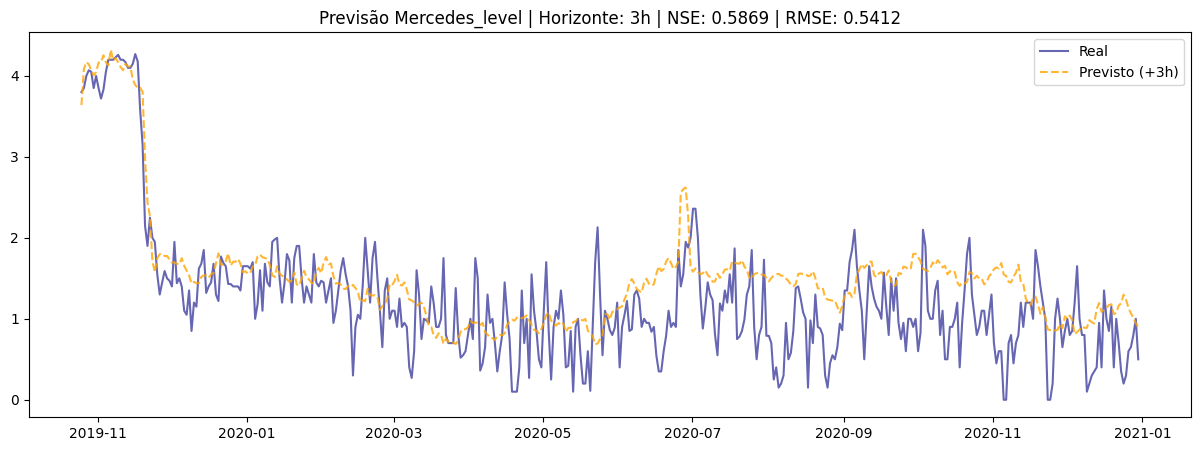

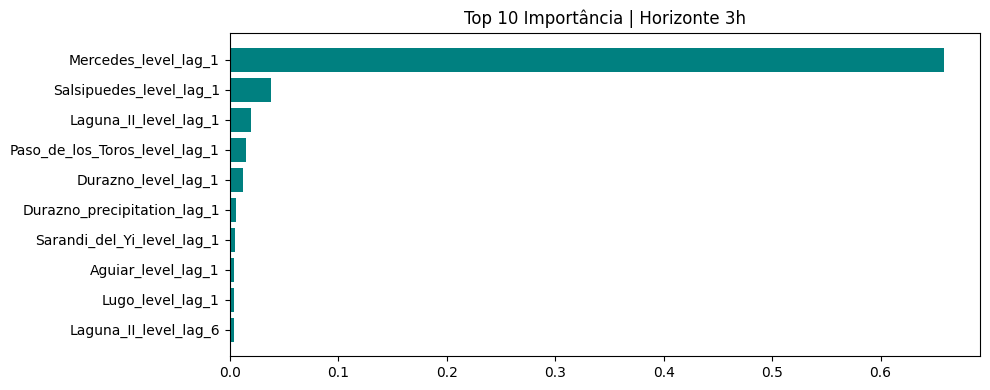


 INICIANDO EXPERIMENTO: Horizonte = 168 horas
Treino: 1600 amostras | Teste: 400 amostras


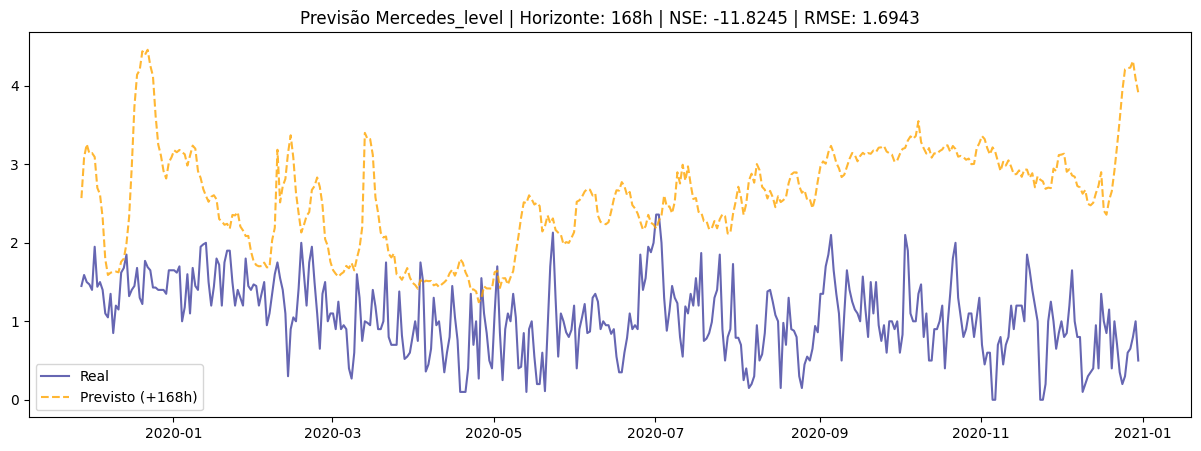

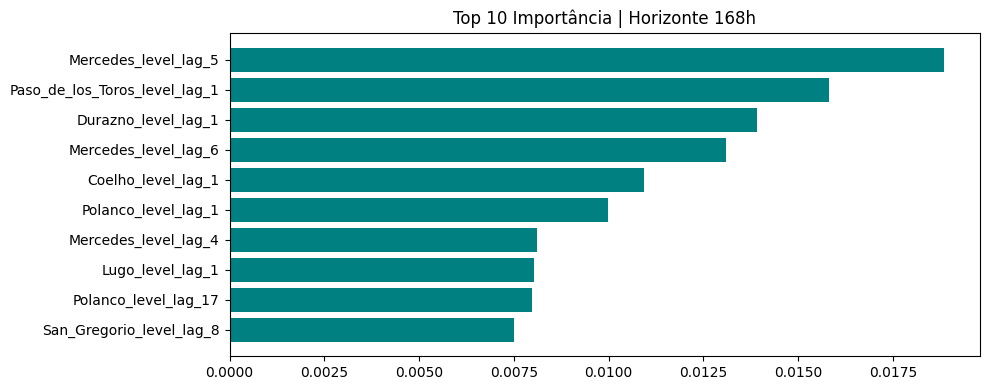

(-11.82445369273233, 1.6943342749004184)

In [35]:
TARGET = 'Mercedes_level'

# --- TESTE 1: Curto Prazo (12 horas) ---
run_baseline_experiment(df, target_col=TARGET, horizon_hours=3)

# --- TESTE 2: Longo Prazo (1 semana / 168 horas) ---
# Nota: Queda drastica na performace, tente criar modelos que também funcionam aqui!
run_baseline_experiment(df, target_col=TARGET, horizon_hours=168)